# Bank Loans 🏦
### "Rate-proof high yield" — do floating-rate bank loans actually protect you when rates rise?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free lunch?: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Senior bank loans (and the ETF that holds a basket of them, **BKLN**) are sold as a *rate-proof* income sleeve: the coupon **floats** with short-term rates, so unlike a bond fund the price barely falls when rates rise. We line BKLN up next to long Treasuries (TLT), intermediate Treasuries (IEF) and stocks (SPY) and ask two questions: does the rate protection actually work — and, if it does, where did the risk *go*?

> 📓 **This is the plain-language layer.** The betas, the HAC *t* and the bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (bank_loans/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from bank_loans import data, strategy

AS_OF = "2026-05-31"
# Try the REAL total-return tapes; fall back to the offline synthetic control if the
# network is blocked. Every cell prints which TAPE it is showing.
try:
    prices = data.load_real(("BKLN", "TLT", "IEF", "SPY")).loc[:AS_OF]
    TAPE = "REAL"
except Exception as e:
    print("network/cache miss -> SYNTHETIC control tape:", type(e).__name__)
    prices, _truth = data.synthetic_four_asset(dur=0.05, credit_beta=0.65, seed=340)
    TAPE = "SYNTHETIC"

BKLN, TLT, IEF, SPY = "BKLN", "TLT", "IEF", "SPY"
rets = strategy.to_returns(prices)
BANNER = ("REAL total-return tape (BKLN/TLT/IEF/SPY, 2011-2026)" if TAPE == "REAL"
          else "SYNTHETIC control tape (dur=0.05, credit_beta=0.65) -- NOT market data")
print(f"[{TAPE}] {BANNER}")
print(f"panel: {len(prices):,} rows  {prices.index[0].date()} -> {prices.index[-1].date()}  fingerprint={data.fingerprint(prices)}")
for c in (BKLN, TLT, IEF, SPY):
    s = strategy.stats(rets[c])
    print(f"  {c}: CAGR {s['cagr']*100:6.2f}%  vol {s['vol']*100:5.1f}%  Sharpe {s['sharpe']:.3f}  maxDD {s['max_dd']*100:6.1f}%")


[REAL] REAL total-return tape (BKLN/TLT/IEF/SPY, 2011-2026)
panel: 3,833 rows  2011-03-03 -> 2026-05-29  fingerprint=a4d0ad1fb115
  BKLN: CAGR   3.73%  vol   5.8%  Sharpe 0.660  maxDD  -24.2%
  TLT: CAGR   2.51%  vol  14.9%  Sharpe 0.241  maxDD  -48.4%
  IEF: CAGR   2.37%  vol   6.5%  Sharpe 0.393  maxDD  -23.9%
  SPY: CAGR  14.10%  vol  17.1%  Sharpe 0.856  maxDD  -33.7%


## The answer first 🎯

| Question | Answer |
|---|---|
| Does BKLN shrug off rate moves? | **Yes** — its beta to long Treasuries is **-0.055** (≈ zero). In the 2020–2023 rate rout that cost TLT **-48.4%**, BKLN *gained* **+13.9%**. |
| So it's low-risk? | **No** — the risk *moved to credit*. BKLN fell in **7 of 7** stock-market crashes; in 2020 it lost **-23.8%** while bonds *rose* **+14.2%**. |
| Is it a free lunch vs bonds? | **No** — you swapped *interest-rate* risk for *credit + liquidity* risk. A modest real sleeve (3.73%/yr, vol 5.8%), not a safe haven. |

> *Headline numbers are the **real** 2011–2026 tape (`docs/results.md`, fingerprint `a4d0ad1fb115`). If the executed cells below show a SYNTHETIC banner, the live data was blocked and the harness fell back to the offline control — the prose numbers still refer to the real run.*

## 1 · The claim

*"Worried about rising rates? Rotate out of bond funds into **floating-rate senior bank loans**. The coupon resets with short-term rates, so the price barely moves when rates go up — you get a fat yield with almost none of the interest-rate risk that hammers a normal bond fund."* It's the pitch every advisor reaches for in a hiking cycle — and BKLN is filed in the *income* bucket, right next to the bonds it's meant to replace.

## 2 · So what?

If the pitch is true, BKLN is the perfect place to hide from a bond bear market — high income, no duration drama. If the rate protection is real *but the risk simply moved somewhere else*, then investors fleeing duration into loans are walking into a different trap — one that springs in a recession instead of a rate hike. The label decides where you put it, and when it hurts you.

## 3 · How would we even know?

Two clean tests. **Rate test:** every time long bonds (TLT) sold off because rates rose, what did BKLN do — fall with them, or shrug? **Credit test:** every time stocks fell more than 10%, did BKLN cushion (like a safe bond) or pile on (like risky credit)? If BKLN passes the first and *fails* the second, the rate protection is real but the safety isn't.

## 4 · The teardown — let's actually look

First, the four equity curves. Watch the calm BKLN line — and watch what it does in 2020.

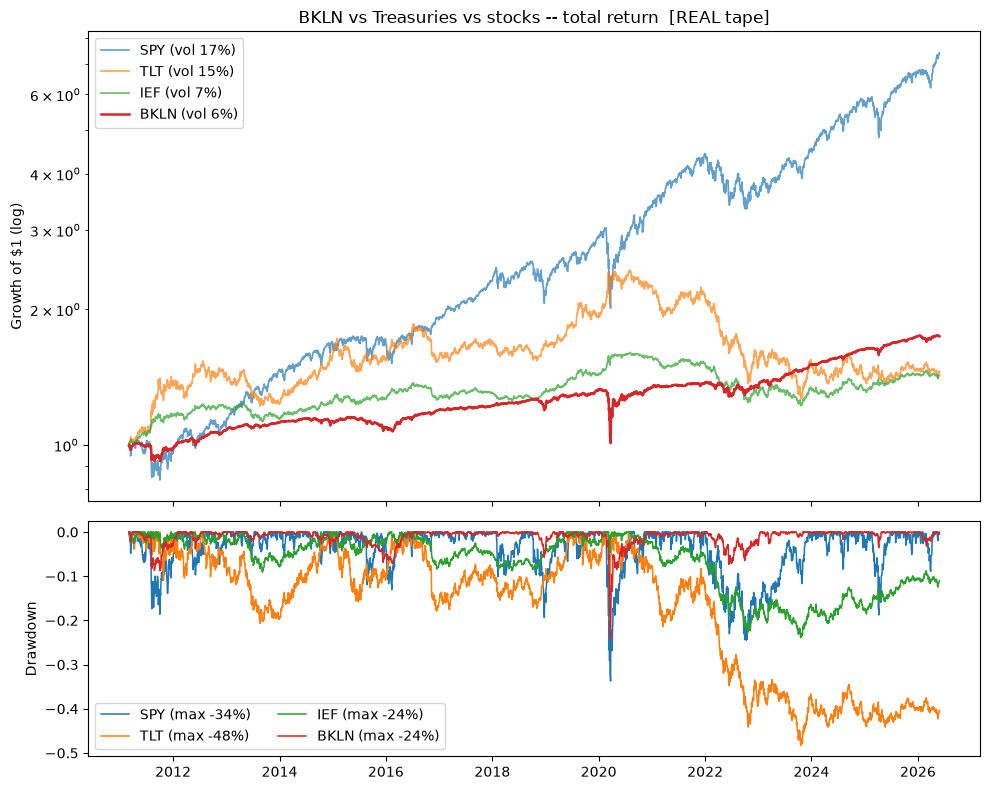

In [2]:
stats = {c: strategy.stats(rets[c]) for c in (BKLN, TLT, IEF, SPY)}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
for c, style in [(SPY, dict(lw=1.2, alpha=.7)), (TLT, dict(lw=1.2, alpha=.7)), (IEF, dict(lw=1.2, alpha=.7)), (BKLN, dict(lw=1.8))]:
    ax1.plot(stats[c]['equity'], label=f"{c} (vol {stats[c]['vol']*100:.0f}%)", **style)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend()
ax1.set_title(f'BKLN vs Treasuries vs stocks -- total return  [{TAPE} tape]')
for c in (SPY, TLT, IEF, BKLN):
    eq = stats[c]['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{c} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(ncol=2); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

BKLN's line is *calm* — far smoother than TLT, smoother even than IEF. That low volatility is the whole sales pitch, and it's not a lie. But notice the one place the BKLN drawdown line plunges: it isn't a rate event, it's a *risk-off* event (2020).

Now the **rate test**. Every time long bonds fell more than 5% on rising rates, here's what BKLN did over the same window:

In [3]:
eps = strategy.asset_drawdowns(rets[[TLT, BKLN, IEF, SPY]], TLT, thresh=-0.05)
rows = [{'peak':e['peak'].date(),'trough':e['trough'].date(),
         f'{TLT} %':e['driver_loss']*100, f'{BKLN} %':e['others'][BKLN]*100, f'{IEF} %':e['others'][IEF]*100} for e in eps]
dd = pd.DataFrame(rows)
print(f'[{TAPE}] in TLT (rate) selloffs, BKLN rose in {(dd[f"{BKLN} %"]>0).sum()}/{len(dd)} episodes')
dd.round(1)

[REAL] in TLT (rate) selloffs, BKLN rose in 8/10 episodes


,peak,trough,TLT %,BKLN %,IEF %
0,2011-08-10,2011-08-11,-5.000,0.000,-1.500
1,2011-10-03,2011-10-27,-10.900,6.000,-4.100
2,2011-12-19,2012-03-19,-10.400,4.600,-3.400
3,2012-07-25,2013-08-21,-20.700,5.600,-7.700
4,2015-01-30,2015-06-26,-15.800,1.100,-5.100
5,2016-07-08,2016-12-14,-17.900,3.100,-8.200
6,2019-08-28,2019-11-08,-8.200,0.700,-3.000
7,2020-03-09,2020-03-18,-15.700,-11.800,-4.700
8,2020-04-21,2020-06-05,-8.600,5.100,-2.000
9,2020-08-04,2023-10-19,-48.400,13.900,-23.900


BKLN passes the rate test cleanly: in the 2020–2023 great repricing TLT lost **-48.4%** and IEF **-23.9%**, while BKLN **gained +13.9%**. The floating coupon does exactly what the brochure says.

Now the **credit test**. Every time stocks fell more than 10%, what did BKLN do?

In [4]:
eps = strategy.asset_drawdowns(rets[[SPY, BKLN, TLT, IEF]], SPY, thresh=-0.10)
rows = [{'peak':e['peak'].date(),'trough':e['trough'].date(),
         f'{SPY} %':e['driver_loss']*100, f'{BKLN} %':e['others'][BKLN]*100, f'{TLT} %':e['others'][TLT]*100} for e in eps]
dd = pd.DataFrame(rows)
bkln_fell = (dd[f'{BKLN} %']<0).sum()
print(f'[{TAPE}] BKLN fell in {bkln_fell}/{len(dd)} equity crashes')
dd.round(1)

[REAL] BKLN fell in 7/7 equity crashes


,peak,trough,SPY %,BKLN %,TLT %
0,2011-04-29,2011-10-03,-18.600,-8.400,34.600
1,2015-07-20,2016-02-11,-13.000,-6.400,14.800
2,2018-01-26,2018-02-08,-10.100,-0.600,-3.800
3,2018-09-20,2018-12-24,-19.300,-5.300,4.500
4,2020-02-19,2020-03-23,-33.700,-23.800,14.200
5,2022-01-03,2022-10-12,-24.500,-4.800,-29.300
6,2025-02-19,2025-04-08,-18.800,-3.400,0.800


On the real tape BKLN fell in **7 of 7** equity crashes. The headline case is COVID: BKLN lost **-23.8%** — a liquidity gap, not a rate move — while Treasuries *gained +14.2%*. The risk didn't disappear; it changed costume from *duration* to *credit + liquidity*.

## 5 · The verdict

- **Signal → Real.** BKLN's rate sensitivity really is ≈ zero (beta to long bonds -0.055, HAC *t* -2.95), and it *rose* through the worst Treasury bear market in decades. The rate protection is statistically real.
- **Tradability → Fragile.** A modest, real income sleeve (3.73%/yr, vol 5.8%) — but it fell in 7/7 crashes and gapped −24% in 2020. Thin in stress, credit-risky, not a safe haven.
- **Free lunch? → Busted.** Low duration is real; *low risk* is not. You traded rate risk for credit risk, and the bill comes due in a recession, not a rate hike.

## 6 · Could you actually trade it?

You *can* buy BKLN in one click, and in calm markets it's liquid and low-vol. The catch is structural: the underlying **leveraged loans** are sub-investment-grade corporate credit that settles in *weeks*, not days, so the ETF rides on top of an illiquid market. In a risk-off shock the fund can gap to a discount — which is exactly what 2020 was. As a *tactical* dodge of duration risk it's defensible; as a *safe* bond substitute it isn't.

## 7 · Going further 🚪

- Split BKLN's return into **coupon vs price**: how much of the 3.7%/yr is the fat coupon vs price erosion in the 2020/2022 stress?
- Compare to **SRLN** (an actively-managed loan ETF) and to **high-yield bonds** (HYG): is the credit-tail behaviour structural to leveraged credit, or fund-specific?
- Build the honest **duration + credit** two-factor regression and read off how much of each BKLN carries — the quants notebook does the single-factor version.